In [1]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd

In [2]:
X , y = make_classification(n_samples=100, n_features=1, n_informative=1, n_redundant=0, n_classes=2 , n_clusters_per_class=1, n_repeated=0, random_state=42)

In [3]:
df = pd.DataFrame(X , columns=[f"Feature{i + 1}" for i in range(X.shape[1])])
df["target"] = y

In [4]:
X.shape

(100, 1)

In [5]:
df

,Feature1,target
0,-1.121978,0
1,-0.708785,0
2,0.426987,1
3,-0.755781,0
4,-1.106984,0
...,...,...
95,-1.174613,0
96,1.266318,1
97,0.799008,1
98,0.835421,1


In [6]:
import matplotlib.pyplot as plt

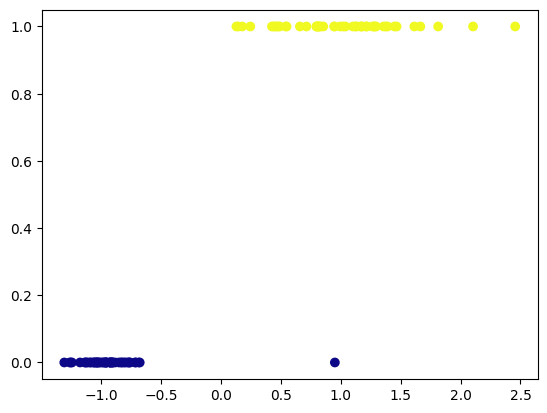

In [7]:
plt.scatter(x = X.reshape(X.shape[0]) , y = y , c = y , cmap="plasma")

## Perceptron trick class

In [8]:
class PerceptronTrick:
    def __init__(self, epochs = 100, learning_rate = 0.01):
        self.m = 0
        self.b = 0
        self.epochs = epochs
        self.lr = learning_rate
    def fit(self,X,y):
        for i in range(self.epochs):
            # select an random point
            row = np.random.randint(0 , X.shape[0])
            y_cap = step( self.m * X[row][0] + self.b)
            self.m = self.m + self.lr * (y[row] - y_cap) * X[row][0]
            self.b = self.b + self.lr * (y[row] - y_cap) 

def step(value):
        return 1 if value >= 0 else 0
    

In [9]:
np.random.randint(1 , X.shape[0])

51

In [10]:
pt = PerceptronTrick(epochs=1000, learning_rate=0.0001)

In [11]:
pt.fit(X,y)

In [12]:
pt.m

np.float64(0.00012474840291612515)

In [13]:
pt.b

np.float64(0.0)

In [14]:
X[0].shape

(1,)

In [15]:
X.shape

(100, 1)

In [16]:
X[0]

array([-1.12197843])

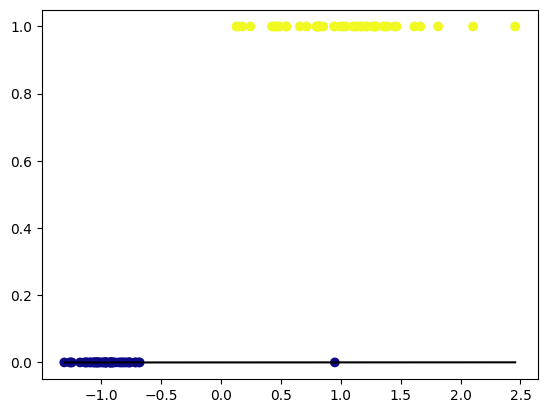

In [17]:
plt.scatter(x = X.reshape(X.shape[0]) , y = y , c = y , cmap="plasma")
# Suppose pt is your trained perceptron object
x_line = np.linspace(X.min(), X.max(), 100)  # 100 evenly spaced x values
y_line = pt.m * x_line + pt.b                # corresponding y values (line equation)
plt.plot(x_line, y_line, color='black', label='Decision boundary')  # plot the line
